# AI-Driven Targeted Marketing Using Review-Based Consumer Behaviour

This notebook builds and compares recommendation models for e-commerce product targeting using ratings, review text, sentiment signals, and customer segmentation.

## 1. Setup and data loading

In [ ]:
import os
import re
import gc
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

SEED = 42
np.random.seed(SEED)


OUTPUT_DIR = Path("project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def find_amazon_csv():
    
    path = "amazon_reviews.csv"
    
    if os.path.exists(path):
        return path
    
    raise FileNotFoundError("amazon_reviews.csv not found in current folder")

file_path = find_amazon_csv()
print("Using:", file_path)

Using: amazon_reviews.csv


In [23]:
wanted_cols = [
    "userName", "verified", "itemName", "description", "image", "brand", "feature",
    "category", "price", "rating", "reviewTime", "summary", "reviewText", "vote"
]

all_cols = pd.read_csv(file_path, nrows=0).columns.tolist()
use_cols = [c for c in wanted_cols if c in all_cols]

raw_df = pd.read_csv(file_path, usecols=use_cols, low_memory=False)
print("Raw shape:", raw_df.shape)
display(raw_df.head(3))

Raw shape: (585505, 14)


,userName,verified,itemName,description,image,brand,feature,category,price,rating,reviewTime,summary,reviewText,vote
0,Amazon Customer,TRUE,"Toblerone Swiss Milk Chocolate Bar, Crunchy Salted Almond, 3.52 Ounce","[""Made from deliciously decadent ingredients, Toblerone's swiss milk chocolate is a delight for any chocolate lover....","['https://images-na.ssl-images-amazon.com/images/I/51ncjOQJQ0L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com...",Toblerone,[],Prime_Pantry,$1.63,5,1/1/2018,Five Stars,super smooth and yummy with crunchy bits,0
1,Carla,TRUE,"Prince of Peace Organic Tea, Oolong, 100 Tea Bags","['Prince of Peace Enterprises, Inc., founded in 1983, earned its reputation as a leading and diversified company, sp...","['https://images-na.ssl-images-amazon.com/images/I/61ZBUFMoWML._SS40_.jpg', 'https://images-na.ssl-images-amazon.com...",Prince Of Peace,[],Grocery_and_Gourmet_Food,$6.40,5,1/1/2018,Five Stars,Perfect for kombucha,0
2,Jaclyn,TRUE,"Pet Champion Adjustable No-Pull Harness, Collar, Leash Matching Bundle Small, Medium, Large Dog","[""The Pet Champion Large/ Extra Large 22-36 inch Chest Bright Polyester Step-In Halter Dog Harness, Pink Lemonade of...","['https://images-na.ssl-images-amazon.com/images/I/41x6wIUiAlL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com...",Pet Champion,"['Features Bright Pink Lemonade pattern', 'Dual D-ring style leash attachment for less tug', 'Made from 1 inch wide ...",Pet_Supplies,$7.99,5,1/1/2018,she has an odd shape chest and her pull over harness was not going over her big head so easy anymore. This harness f...,Finally a harness that fits my puppy. I really was in need of a harness that fits my 7 pound pug Chihuahua mix.she h...,0


## 2. Cleaning and feature preparation

In [24]:
df = raw_df.copy()

rename_map = {
    "userName": "user_name",
    "itemName": "item_name",
    "reviewTime": "review_time",
    "reviewText": "review_text",
}
df = df.rename(columns=rename_map)

def clean_text(x):
    x = "" if pd.isna(x) else str(x)
    x = x.lower()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"\S+@\S+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def to_verified_num(x):
    s = str(x).strip().lower()
    if s in {"true", "1", "yes"}:
        return 1
    if s in {"false", "0", "no"}:
        return 0
    return 0

def price_to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    matches = re.findall(r"\d+(?:\.\d+)?", s.replace(",", ""))
    if not matches:
        return np.nan
    try:
        return float(matches[0])
    except Exception:
        return np.nan

def vote_to_num(x):
    if pd.isna(x):
        return 0.0
    s = str(x).replace(",", "").strip()
    if s == "":
        return 0.0
    nums = re.findall(r"\d+(?:\.\d+)?", s)
    if not nums:
        return 0.0
    try:
        return float(nums[0])
    except Exception:
        return 0.0

if "rating" in df.columns:
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
if "review_time" in df.columns:
    df["review_time"] = pd.to_datetime(df["review_time"], errors="coerce")
if "verified" in df.columns:
    df["verified_num"] = df["verified"].apply(to_verified_num)
else:
    df["verified_num"] = 0
if "price" in df.columns:
    df["price_num"] = df["price"].apply(price_to_num)
else:
    df["price_num"] = np.nan
if "vote" in df.columns:
    df["vote_num"] = df["vote"].apply(vote_to_num)
else:
    df["vote_num"] = 0.0

for col in ["user_name", "item_name", "brand", "category", "summary", "review_text"]:
    if col not in df.columns:
        df[col] = ""

df["summary"] = df["summary"].fillna("").astype(str)
df["review_text"] = df["review_text"].fillna("").astype(str)
df["summary_clean"] = df["summary"].apply(clean_text)
df["review_text_clean"] = df["review_text"].apply(clean_text)
df["text"] = (df["summary_clean"] + " " + df["review_text_clean"]).str.strip()

# remove rows missing core fields
df = df.dropna(subset=["user_name", "item_name", "rating"]).copy()
df = df[df["user_name"].astype(str).str.strip() != ""].copy()
df = df[df["item_name"].astype(str).str.strip() != ""].copy()

# drop duplicate exact interactions where possible
dup_cols = [c for c in ["user_name", "item_name", "brand", "category", "rating", "review_time", "summary_clean", "review_text_clean"] if c in df.columns]
if dup_cols:
    df = df.drop_duplicates(subset=dup_cols).copy()

# make internal IDs
df["product_key"] = (
    df["item_name"].fillna("").astype(str).str.strip() + " | " +
    df["brand"].fillna("").astype(str).str.strip() + " | " +
    df["category"].fillna("").astype(str).str.strip()
)

df["user_id"] = pd.factorize(df["user_name"].astype(str).str.strip(), sort=False)[0].astype(int)
df["item_id"] = pd.factorize(df["product_key"], sort=False)[0].astype(int)

# keep cleaned columns useful for modelling
keep_cols = [
    "user_id", "item_id", "item_name", "brand", "category", "price_num", "rating",
    "review_time", "verified_num", "vote_num", "summary_clean", "review_text_clean", "text"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

print("Cleaned shape:", df.shape)
print("Unique users:", df["user_id"].nunique())
print("Unique items:", df["item_id"].nunique())
display(df.head(3))

Cleaned shape: (504948, 13)
Unique users: 130883
Unique items: 109216


,user_id,item_id,item_name,brand,category,price_num,rating,review_time,verified_num,vote_num,summary_clean,review_text_clean,text
0,0,0,"Toblerone Swiss Milk Chocolate Bar, Crunchy Salted Almond, 3.52 Ounce",Toblerone,Prime_Pantry,1.63,5.0,2018-01-01,1,0.0,five stars,super smooth and yummy with crunchy bits,five stars super smooth and yummy with crunchy bits
1,1,1,"Prince of Peace Organic Tea, Oolong, 100 Tea Bags",Prince Of Peace,Grocery_and_Gourmet_Food,6.40,5.0,2018-01-01,1,0.0,five stars,perfect for kombucha,five stars perfect for kombucha
2,2,2,"Pet Champion Adjustable No-Pull Harness, Collar, Leash Matching Bundle Small, Medium, Large Dog",Pet Champion,Pet_Supplies,7.99,5.0,2018-01-01,1,0.0,she has an odd shape chest and her pull over harness was not going over her big head so easy anymore this harness fi...,finally a harness that fits my puppy i really was in need of a harness that fits my 7 pound pug chihuahua mix she ha...,she has an odd shape chest and her pull over harness was not going over her big head so easy anymore this harness fi...


## 3. Review sentiment and rating–text mismatch

In [25]:
positive_words = {
    "good", "great", "excellent", "amazing", "love", "perfect", "best", "awesome",
    "fantastic", "happy", "satisfied", "smooth", "comfortable", "durable", "nice",
    "recommend", "recommended", "useful", "strong", "easy", "works", "quality", "beautiful"
}
negative_words = {
    "bad", "poor", "terrible", "awful", "worst", "hate", "broken", "waste", "cheap",
    "disappointed", "problem", "problems", "refund", "return", "damaged", "hard", "difficult",
    "uncomfortable", "wrong", "fake", "defective", "weak", "mess", "boring", "useless"
}

def sentiment_features(text):
    words = str(text).split()
    if not words:
        return pd.Series({"pos_count": 0, "neg_count": 0, "sent_score": 0.0})
    pos_count = sum(1 for w in words if w in positive_words)
    neg_count = sum(1 for w in words if w in negative_words)
    sent_score = (pos_count - neg_count) / max(len(words), 1)
    return pd.Series({"pos_count": pos_count, "neg_count": neg_count, "sent_score": sent_score})

sent_df = df["text"].apply(sentiment_features)
df = pd.concat([df, sent_df], axis=1)

df["rating_norm"] = (df["rating"] - 1.0) / 4.0
df["sent_norm"] = (df["sent_score"] + 1.0) / 2.0
df["rating_sent_gap"] = (df["rating_norm"] - df["sent_norm"]).abs()

display(df[["rating", "text", "pos_count", "neg_count", "sent_score", "rating_sent_gap"]].head(3))

,rating,text,pos_count,neg_count,sent_score,rating_sent_gap
0,5.0,five stars super smooth and yummy with crunchy bits,1.0,0.0,0.111111,0.444444
1,5.0,five stars perfect for kombucha,1.0,0.0,0.200000,0.400000
2,5.0,she has an odd shape chest and her pull over harness was not going over her big head so easy anymore this harness fi...,2.0,0.0,0.019608,0.490196


## 4. Dataset summary

In [26]:
dataset_summary = pd.DataFrame({
    "Measure": [
        "Rows",
        "Unique users",
        "Unique items",
        "Unique categories",
        "Average rating",
        "Average price",
        "Average sentiment",
        "Average rating-sentiment gap"
    ],
    "Value": [
        len(df),
        df["user_id"].nunique(),
        df["item_id"].nunique(),
        df["category"].nunique(),
        round(df["rating"].mean(), 4),
        round(df["price_num"].mean(skipna=True), 4),
        round(df["sent_score"].mean(), 6),
        round(df["rating_sent_gap"].mean(), 6),
    ]
})
print("Table I. Dataset summary")
display(dataset_summary)

Table I. Dataset summary


,Measure,Value
0,Rows,504948.000000
1,Unique users,130883.000000
2,Unique items,109216.000000
3,Unique categories,16.000000
4,Average rating,4.343600
5,Average price,20.359000
6,Average sentiment,0.085225
7,Average rating-sentiment gap,0.377961


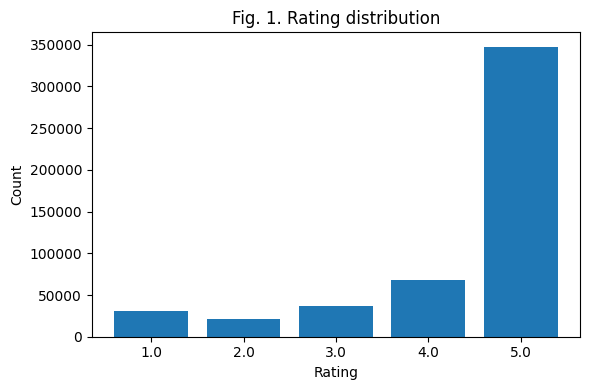

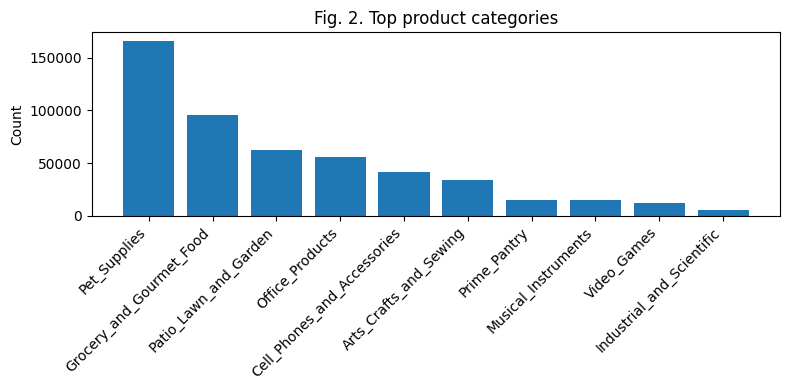

In [27]:
# Fig. 1 rating distribution
rating_counts = df["rating"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Fig. 1. Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Fig. 2 top categories
top_categories = df["category"].fillna("Unknown").value_counts().head(10)
plt.figure(figsize=(8,4))
plt.bar(top_categories.index.astype(str), top_categories.values)
plt.title("Fig. 2. Top product categories")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 5. Train and test split for the broad targeted-marketing evaluation

In [28]:
# broad split: users with at least 2 interactions
user_counts = df["user_id"].value_counts()
broad_users = user_counts[user_counts >= 2].index
broad_df = df[df["user_id"].isin(broad_users)].copy()
broad_df = broad_df.sort_values(["user_id", "review_time"]).reset_index(drop=True)

test_idx = broad_df.groupby("user_id").tail(1).index
broad_test = broad_df.loc[test_idx].copy()
broad_train = broad_df.drop(index=test_idx).copy()

print("Broad train shape:", broad_train.shape)
print("Broad test shape:", broad_test.shape)
print("Broad evaluable users:", broad_test["user_id"].nunique())

Broad train shape: (374065, 19)
Broad test shape: (76047, 19)
Broad evaluable users: 76047


## 6. Metric functions

In [29]:
def precision_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    predicted = list(predicted)[:k]
    return len(set(actual).intersection(predicted)) / float(k)

def recall_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    predicted = list(predicted)[:k]
    return len(set(actual).intersection(predicted)) / float(len(set(actual)))

def dcg_at_k(actual, predicted, k=10):
    predicted = list(predicted)[:k]
    score = 0.0
    for i, item in enumerate(predicted):
        if item in actual:
            score += 1.0 / math.log2(i + 2)
    return score

def ndcg_at_k(actual, predicted, k=10):
    ideal = min(len(set(actual)), k)
    if ideal == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal))
    return dcg_at_k(actual, predicted, k) / idcg

def average_precision_at_k(actual, predicted, k=10):
    if not actual:
        return 0.0
    predicted = list(predicted)[:k]
    hits = 0
    score = 0.0
    seen = set()
    for i, item in enumerate(predicted, start=1):
        if item in actual and item not in seen:
            hits += 1
            score += hits / i
            seen.add(item)
    return score / min(len(set(actual)), k) if len(set(actual)) > 0 else 0.0

def evaluate_recommender(eval_users, truth_map, recommender_fn, k=10):
    precision_scores, recall_scores, ndcg_scores, map_scores = [], [], [], []
    for uid in eval_users:
        actual = truth_map.get(uid, set())
        preds = recommender_fn(uid, k=k)
        precision_scores.append(precision_at_k(actual, preds, k))
        recall_scores.append(recall_at_k(actual, preds, k))
        ndcg_scores.append(ndcg_at_k(actual, preds, k))
        map_scores.append(average_precision_at_k(actual, preds, k))
    return {
        f"Precision@{k}": float(np.mean(precision_scores)) if precision_scores else 0.0,
        f"Recall@{k}": float(np.mean(recall_scores)) if recall_scores else 0.0,
        f"NDCG@{k}": float(np.mean(ndcg_scores)) if ndcg_scores else 0.0,
        f"MAP@{k}": float(np.mean(map_scores)) if map_scores else 0.0,
        "n_users": len(eval_users),
    }

broad_train_user_items = broad_train.groupby("user_id")["item_id"].apply(set).to_dict()
broad_test_user_items = broad_test.groupby("user_id")["item_id"].apply(set).to_dict()
broad_eval_users = sorted(set(broad_train_user_items.keys()) & set(broad_test_user_items.keys()))

print("Broad evaluation users:", len(broad_eval_users))

Broad evaluation users: 76047


## 7. Model 1: Popularity baseline

In [30]:
global_mean_rating = broad_train["rating"].mean()
min_support = 10

item_stats = (
    broad_train.groupby("item_id")
    .agg(
        item_name=("item_name", "first"),
        brand=("brand", "first"),
        category=("category", "first"),
        support_count=("item_id", "size"),
        avg_rating=("rating", "mean"),
        avg_price=("price_num", "mean"),
        avg_sentiment=("sent_score", "mean"),
    )
    .reset_index()
)

item_stats["weighted_score"] = (
    (item_stats["support_count"] / (item_stats["support_count"] + min_support)) * item_stats["avg_rating"] +
    (min_support / (item_stats["support_count"] + min_support)) * global_mean_rating
)

item_stats = item_stats.sort_values(["weighted_score", "support_count"], ascending=False).reset_index(drop=True)
display(item_stats.head(10))

,item_id,item_name,brand,category,support_count,avg_rating,avg_price,avg_sentiment,weighted_score
0,106993,"CeeOne 27W 5.4A Dual-Port Type C USB Car Charger with Built-in 3.3FT USB Type C Cable for Apple New Macbook 12 Inch,...",TNSO,Cell_Phones_and_Accessories,54,5.000000,NaN,0.119831,4.901872
1,20841,PowerLead Wireless Controller Gamepad for Nintendo Wii U Bluetooth Game Controller Joystick Gamepad,PowerLead,Video_Games,120,4.941667,NaN,0.065761,4.897845
2,3624,Hatortempt 5 lbs Dried Mealworms for Wild Bird Chicken Fish,Hatortempt,Patio_Lawn_and_Garden,46,4.956522,27.88,0.099490,4.852139
3,1258,"D'Addario EXL120+ Nickel Wound Electric Guitar Strings, Super Light Plus, 9.5-44",D'Addario,Musical_Instruments,99,4.898990,4.49,0.104152,4.850640
4,10048,"Pilot G2 Retractable Premium Gel Ink Roller Ball Pens Fine Pt (.7) Dozen Box Red ; Retractable, Refillable &amp; Pre...",Pilot,Office_Products,75,4.906667,14.79,0.115051,4.843762
5,10448,"Blueberry Pet Soft &amp; Comfy 3M Reflective Pastel Color Padded Dog Collar, Matching Leash &amp; Harness Available ...",Blueberry Pet,Pet_Supplies,36,4.972222,13.99,0.121388,4.841735
6,30803,Grace Alley American Flag: American Made 3x5 FT US Flag Made In USA - Embroidered Stars and Sewn Stripes. This Ameri...,Grace Alley,Patio_Lawn_and_Garden,29,5.000000,29.62,0.118191,4.838969
7,108987,ELenest 2 Handles Dog Leash - 8FT 2Inch Green Dual Handle Dog Leash - Free Bonus Dog Tag - Dog Leashes for Large Dog...,ELenest,Pet_Supplies,28,5.000000,NaN,0.030982,4.834732
8,10583,"Nutiva Organic, non-GMO, Premium Ground Chia Seeds",Nutiva,Grocery_and_Gourmet_Food,40,4.950000,NaN,0.161186,4.834396
9,5548,Purina Friskies Party Mix Favorites Lip Lickin' Chicken Cat Treats,Purina Friskies Party Mix,Pet_Supplies,43,4.930233,NaN,0.091409,4.824902


In [31]:
def recommend_popularity(user_id, k=10):
    seen = broad_train_user_items.get(user_id, set())
    recs = []
    for item in item_stats["item_id"].tolist():
        if item not in seen:
            recs.append(int(item))
        if len(recs) == k:
            break
    return recs

results_pop_broad = evaluate_recommender(
    broad_eval_users,
    broad_test_user_items,
    recommend_popularity,
    k=10
)

print("Popularity baseline results:")
print(results_pop_broad)

Popularity baseline results:
{'Precision@10': 8.284350467474063e-05, 'Recall@10': 0.0008284350467474062, 'NDCG@10': 0.0003119832763509613, 'MAP@10': 0.0001588720926761875, 'n_users': 76047}


## 8. Model 2: TF-IDF + sentiment hybrid

In [32]:
item_profile_full = (
    broad_train.groupby("item_id")
    .agg(
        text=("text", lambda x: " ".join(x.astype(str))),
        item_name=("item_name", "first"),
        brand=("brand", "first"),
        category=("category", "first"),
        avg_rating=("rating", "mean"),
        interaction_count=("item_id", "size"),
        verified_ratio=("verified_num", "mean"),
        avg_vote=("vote_num", "mean"),
        avg_sentiment=("sent_score", "mean"),
        avg_gap=("rating_sent_gap", "mean"),
    )
    .reset_index()
)

for col in ["avg_rating", "interaction_count", "verified_ratio", "avg_vote", "avg_sentiment", "avg_gap"]:
    item_profile_full[col] = item_profile_full[col].fillna(0)

tfidf_full = TfidfVectorizer(
    max_features=4000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)
item_matrix_full = tfidf_full.fit_transform(item_profile_full["text"].fillna(""))

item_to_row_full = {item_id: i for i, item_id in enumerate(item_profile_full["item_id"])}

scale_full = MinMaxScaler()
scaled_full = scale_full.fit_transform(
    item_profile_full[["avg_rating", "interaction_count", "verified_ratio", "avg_vote", "avg_sentiment", "avg_gap"]]
)
item_profile_full["rating_score_norm"] = scaled_full[:, 0]
item_profile_full["popularity_score_norm"] = scaled_full[:, 1]
item_profile_full["verified_score_norm"] = scaled_full[:, 2]
item_profile_full["vote_score_norm"] = scaled_full[:, 3]
item_profile_full["sentiment_score_norm"] = scaled_full[:, 4]
item_profile_full["gap_score_norm"] = scaled_full[:, 5]

broad_user_categories = broad_train.groupby("user_id")["category"].apply(list).to_dict()

In [33]:
def recommend_tfidf_hybrid_full(
    user_id,
    k=10,
    w_text=0.60,
    w_rating=0.15,
    w_pop=0.10,
    w_verified=0.05,
    w_sent=0.10,
    w_gap=0.10,
    w_cat=0.10,
):
    seen = broad_train_user_items.get(user_id, set())
    if len(seen) == 0:
        return recommend_popularity(user_id, k=k)

    seen_rows = [item_to_row_full[i] for i in seen if i in item_to_row_full]
    if len(seen_rows) == 0:
        return recommend_popularity(user_id, k=k)

    user_profile = item_matrix_full[seen_rows].mean(axis=0)
    user_profile = np.asarray(user_profile).reshape(1, -1)

    # candidate shortlist based on dominant categories, then popularity
    user_cats = broad_user_categories.get(user_id, [])
    dominant = pd.Series(user_cats).value_counts().head(2).index.tolist() if len(user_cats) else []

    temp = item_profile_full.copy()
    temp = temp[~temp["item_id"].isin(seen)].copy()

    if dominant:
        temp["category_bonus"] = temp["category"].isin(dominant).astype(int)
        candidate_pool = temp.sort_values(["category_bonus", "interaction_count"], ascending=False).head(1200).copy()
    else:
        temp["category_bonus"] = 0
        candidate_pool = temp.sort_values("interaction_count", ascending=False).head(1200).copy()

    candidate_rows = candidate_pool["item_id"].map(item_to_row_full).tolist()
    sim_scores = cosine_similarity(user_profile, item_matrix_full[candidate_rows]).flatten()

    candidate_pool["text_score"] = sim_scores
    candidate_pool["final_score"] = (
        w_text * candidate_pool["text_score"] +
        w_rating * candidate_pool["rating_score_norm"] +
        w_pop * candidate_pool["popularity_score_norm"] +
        w_verified * candidate_pool["verified_score_norm"] +
        w_sent * candidate_pool["sentiment_score_norm"] -
        w_gap * candidate_pool["gap_score_norm"] +
        w_cat * candidate_pool["category_bonus"]
    )
    return candidate_pool.sort_values("final_score", ascending=False)["item_id"].head(k).astype(int).tolist()

results_tfidf_broad = evaluate_recommender(
    broad_eval_users,
    broad_test_user_items,
    lambda user_id, k=10: recommend_tfidf_hybrid_full(user_id, k=k),
    k=10
)

print("TF-IDF + sentiment hybrid results:")
print(results_tfidf_broad)

TF-IDF + sentiment hybrid results:
{'Precision@10': 0.006332925690691283, 'Recall@10': 0.06332925690691284, 'NDCG@10': 0.0475670457179505, 'MAP@10': 0.04278433387372596, 'n_users': 76047}


## 9. Dense subset for tuning and advanced models

In [34]:
def density_filter(data, min_user=2, min_item=3, loops=3):
    temp = data.copy()
    for _ in range(loops):
        user_counts = temp["user_id"].value_counts()
        item_counts = temp["item_id"].value_counts()
        temp = temp[temp["user_id"].isin(user_counts[user_counts >= min_user].index)]
        temp = temp[temp["item_id"].isin(item_counts[item_counts >= min_item].index)]
    return temp.copy()

candidate_settings = [(2, 3), (2, 5), (3, 3), (3, 5)]
dense_candidates = []

for mu, mi in candidate_settings:
    temp = density_filter(df, min_user=mu, min_item=mi, loops=3)
    temp = temp.sort_values(["user_id", "review_time"]).reset_index(drop=True)

    # users need at least 3 interactions for train/val/test
    uc = temp["user_id"].value_counts()
    temp = temp[temp["user_id"].isin(uc[uc >= 3].index)].copy()

    dense_candidates.append({
        "setting": (mu, mi),
        "rows": len(temp),
        "users": temp["user_id"].nunique(),
        "items": temp["item_id"].nunique(),
    })

dense_candidates = pd.DataFrame(dense_candidates).sort_values(["users", "rows"], ascending=False).reset_index(drop=True)
print("Dense subset candidates")
display(dense_candidates)

best_setting = tuple(dense_candidates.iloc[0]["setting"])
print("Chosen dense setting:", best_setting)

dense_df = density_filter(df, min_user=best_setting[0], min_item=best_setting[1], loops=3)
uc = dense_df["user_id"].value_counts()
dense_df = dense_df[dense_df["user_id"].isin(uc[uc >= 3].index)].copy()
dense_df = dense_df.sort_values(["user_id", "review_time"]).reset_index(drop=True)

test_idx = dense_df.groupby("user_id").tail(1).index
remaining = dense_df.drop(index=test_idx)
val_idx = remaining.groupby("user_id").tail(1).index

dense_test = dense_df.loc[test_idx].copy()
dense_val = dense_df.loc[val_idx].copy()
dense_train = dense_df.drop(index=list(test_idx) + list(val_idx)).copy()

dense_train_user_items = dense_train.groupby("user_id")["item_id"].apply(set).to_dict()
dense_val_user_items = dense_val.groupby("user_id")["item_id"].apply(set).to_dict()
dense_test_user_items = dense_test.groupby("user_id")["item_id"].apply(set).to_dict()

dense_val_users = sorted(set(dense_train_user_items.keys()) & set(dense_val_user_items.keys()))
dense_test_users = sorted(set(dense_train_user_items.keys()) & set(dense_test_user_items.keys()))

print("Dense train shape:", dense_train.shape)
print("Dense val shape:", dense_val.shape)
print("Dense test shape:", dense_test.shape)
print("Dense evaluation users:", len(dense_test_users))

Dense subset candidates


,setting,rows,users,items
0,"(2, 3)",307158,41645,38047
1,"(3, 3)",296046,40343,33345
2,"(2, 5)",242599,34159,20174
3,"(3, 5)",226903,32164,16804


Chosen dense setting: (2, 3)
Dense train shape: (223868, 19)
Dense val shape: (41645, 19)
Dense test shape: (41645, 19)
Dense evaluation users: 41645


## 10. Tune the TF-IDF hybrid on the dense subset

In [35]:
item_profile_dense = (
    dense_train.groupby("item_id")
    .agg(
        text=("text", lambda x: " ".join(x.astype(str))),
        item_name=("item_name", "first"),
        brand=("brand", "first"),
        category=("category", "first"),
        avg_rating=("rating", "mean"),
        interaction_count=("item_id", "size"),
        verified_ratio=("verified_num", "mean"),
        avg_vote=("vote_num", "mean"),
        avg_sentiment=("sent_score", "mean"),
        avg_gap=("rating_sent_gap", "mean"),
        avg_pos_count=("pos_count", "mean"),
        avg_neg_count=("neg_count", "mean"),
    )
    .reset_index()
)

for col in ["avg_rating", "interaction_count", "verified_ratio", "avg_vote", "avg_sentiment", "avg_gap", "avg_pos_count", "avg_neg_count"]:
    item_profile_dense[col] = item_profile_dense[col].fillna(0)

tfidf_dense = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)
item_matrix_dense = tfidf_dense.fit_transform(item_profile_dense["text"].fillna(""))
item_to_row_dense = {item_id: i for i, item_id in enumerate(item_profile_dense["item_id"])}

scale_dense = MinMaxScaler()
scaled_dense = scale_dense.fit_transform(
    item_profile_dense[["avg_rating", "interaction_count", "verified_ratio", "avg_vote", "avg_sentiment", "avg_gap"]]
)
item_profile_dense["rating_score_norm"] = scaled_dense[:, 0]
item_profile_dense["popularity_score_norm"] = scaled_dense[:, 1]
item_profile_dense["verified_score_norm"] = scaled_dense[:, 2]
item_profile_dense["vote_score_norm"] = scaled_dense[:, 3]
item_profile_dense["sentiment_score_norm"] = scaled_dense[:, 4]
item_profile_dense["gap_score_norm"] = scaled_dense[:, 5]

dense_user_categories = dense_train.groupby("user_id")["category"].apply(list).to_dict()

def recommend_tfidf_dense(
    user_id,
    k=10,
    w_text=0.60,
    w_rating=0.15,
    w_pop=0.10,
    w_verified=0.05,
    w_sent=0.10,
    w_gap=0.10,
    w_cat=0.10,
):
    seen = dense_train_user_items.get(user_id, set())
    if len(seen) == 0:
        return []
    seen_rows = [item_to_row_dense[i] for i in seen if i in item_to_row_dense]
    if len(seen_rows) == 0:
        return []
    user_profile = item_matrix_dense[seen_rows].mean(axis=0)
    user_profile = np.asarray(user_profile).reshape(1, -1)

    user_cats = dense_user_categories.get(user_id, [])
    dominant = pd.Series(user_cats).value_counts().head(2).index.tolist() if len(user_cats) else []

    temp = item_profile_dense.copy()
    temp = temp[~temp["item_id"].isin(seen)].copy()
    if dominant:
        temp["category_bonus"] = temp["category"].isin(dominant).astype(int)
    else:
        temp["category_bonus"] = 0

    temp = temp.sort_values(["category_bonus", "interaction_count"], ascending=False).head(800).copy()
    rows = temp["item_id"].map(item_to_row_dense).tolist()
    temp["text_score"] = cosine_similarity(user_profile, item_matrix_dense[rows]).flatten()

    temp["final_score"] = (
        w_text * temp["text_score"] +
        w_rating * temp["rating_score_norm"] +
        w_pop * temp["popularity_score_norm"] +
        w_verified * temp["verified_score_norm"] +
        w_sent * temp["sentiment_score_norm"] -
        w_gap * temp["gap_score_norm"] +
        w_cat * temp["category_bonus"]
    )
    return temp.sort_values("final_score", ascending=False)["item_id"].head(k).astype(int).tolist()

In [36]:
tuning_configs = [
    {"w_text": 0.65, "w_rating": 0.10, "w_pop": 0.10, "w_verified": 0.05, "w_sent": 0.10, "w_gap": 0.10, "w_cat": 0.10},
    {"w_text": 0.60, "w_rating": 0.15, "w_pop": 0.10, "w_verified": 0.05, "w_sent": 0.10, "w_gap": 0.10, "w_cat": 0.10},
    {"w_text": 0.55, "w_rating": 0.20, "w_pop": 0.10, "w_verified": 0.05, "w_sent": 0.10, "w_gap": 0.10, "w_cat": 0.10},
    {"w_text": 0.50, "w_rating": 0.15, "w_pop": 0.10, "w_verified": 0.05, "w_sent": 0.15, "w_gap": 0.10, "w_cat": 0.10},
    {"w_text": 0.45, "w_rating": 0.20, "w_pop": 0.10, "w_verified": 0.05, "w_sent": 0.15, "w_gap": 0.10, "w_cat": 0.15},
]

tuning_rows = []
best_cfg = tuning_configs[0]
best_ndcg = -1

for cfg in tuning_configs:
    results = evaluate_recommender(
        dense_val_users,
        dense_val_user_items,
        lambda user_id, k=10, cfg=cfg: recommend_tfidf_dense(user_id, k=k, **cfg),
        k=10
    )
    row = {**cfg, **results}
    tuning_rows.append(row)
    if results["NDCG@10"] > best_ndcg:
        best_ndcg = results["NDCG@10"]
        best_cfg = cfg

tuning_table = pd.DataFrame(tuning_rows).sort_values(["NDCG@10", "Precision@10", "Recall@10"], ascending=False).reset_index(drop=True)
print("Table III. Best TF-IDF tuning configurations")
display(tuning_table)
print("Best config:", best_cfg)

Table III. Best TF-IDF tuning configurations


,w_text,w_rating,w_pop,w_verified,w_sent,w_gap,w_cat,Precision@10,Recall@10,NDCG@10,MAP@10,n_users
0,0.65,0.10,0.1,0.05,0.10,0.1,0.10,0.008534,0.085340,0.062158,0.054935,41645
1,0.60,0.15,0.1,0.05,0.10,0.1,0.10,0.008534,0.085340,0.061949,0.054674,41645
2,0.50,0.15,0.1,0.05,0.15,0.1,0.10,0.008481,0.084812,0.061389,0.054097,41645
3,0.55,0.20,0.1,0.05,0.10,0.1,0.10,0.008455,0.084548,0.061341,0.054114,41645
4,0.45,0.20,0.1,0.05,0.15,0.1,0.15,0.008397,0.083972,0.060562,0.053275,41645


Best config: {'w_text': 0.65, 'w_rating': 0.1, 'w_pop': 0.1, 'w_verified': 0.05, 'w_sent': 0.1, 'w_gap': 0.1, 'w_cat': 0.1}


In [37]:
results_tfidf_dense = evaluate_recommender(
    dense_test_users,
    dense_test_user_items,
    lambda user_id, k=10: recommend_tfidf_dense(user_id, k=k, **best_cfg),
    k=10
)
print("Tuned TF-IDF dense results:")
print(results_tfidf_dense)

Tuned TF-IDF dense results:
{'Precision@10': 0.006437747628766959, 'Recall@10': 0.06437747628766959, 'NDCG@10': 0.044014721836338054, 'MAP@10': 0.03760405887251846, 'n_users': 41645}


## 11. Model 3: Matrix factorisation

In [ ]:
# dense popularity baseline for comparison
global_mean_dense = dense_train["rating"].mean()
item_stats_dense = (
    dense_train.groupby("item_id")
    .agg(
        item_name=("item_name", "first"),
        brand=("brand", "first"),
        category=("category", "first"),
        support_count=("item_id", "size"),
        avg_rating=("rating", "mean"),
    )
    .reset_index()
)
item_stats_dense["weighted_score"] = (
    (item_stats_dense["support_count"] / (item_stats_dense["support_count"] + 5)) * item_stats_dense["avg_rating"] +
    (5 / (item_stats_dense["support_count"] + 5)) * global_mean_dense
)
item_stats_dense = item_stats_dense.sort_values(["weighted_score", "support_count"], ascending=False).reset_index(drop=True)

def recommend_popularity_dense(user_id, k=10):
    seen = dense_train_user_items.get(user_id, set())
    recs = []
    for item in item_stats_dense["item_id"].tolist():
        if item not in seen:
            recs.append(int(item))
        if len(recs) == k:
            break
    return recs


dense_user_ids = sorted(dense_train["user_id"].unique())
dense_item_ids = sorted(dense_train["item_id"].unique())
u_to_idx = {u: i for i, u in enumerate(dense_user_ids)}
i_to_idx = {i: j for j, i in enumerate(dense_item_ids)}

user_mean = dense_train.groupby("user_id")["rating"].mean().to_dict()
rows = dense_train["user_id"].map(u_to_idx).astype(int).values
cols = dense_train["item_id"].map(i_to_idx).astype(int).values
vals = (dense_train["rating"] - dense_train["user_id"].map(user_mean)).astype(float).values

R = csr_matrix((vals, (rows, cols)), shape=(len(dense_user_ids), len(dense_item_ids)))
n_components = min(40, max(2, min(R.shape) - 1))
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
user_factors = svd.fit_transform(R)
item_factors = svd.components_.T

item_meta_dense = item_stats_dense.drop_duplicates(subset=["item_id"]).copy()

def recommend_mf_dense(user_id, k=10):
    if user_id not in u_to_idx:
        return recommend_popularity_dense(user_id, k=k)

    seen = dense_train_user_items.get(user_id, set())
    u_idx = u_to_idx[user_id]
    scores = user_factors[u_idx].dot(item_factors.T)

    candidate_items = []
    for item_id, item_idx in i_to_idx.items():
        if item_id not in seen:
            candidate_items.append((item_id, scores[item_idx]))

    candidate_items = sorted(candidate_items, key=lambda x: x[1], reverse=True)[:k]
    return [int(i) for i, _ in candidate_items]

results_pop_dense = evaluate_recommender(dense_test_users, dense_test_user_items, recommend_popularity_dense, k=10)
results_mf_dense = evaluate_recommender(dense_test_users, dense_test_user_items, recommend_mf_dense, k=10)

print("Dense popularity results:")
print(results_pop_dense)
print("Matrix factorisation results:")
print(results_mf_dense)

Dense popularity results:
{'Precision@10': 0.00011525993516628647, 'Recall@10': 0.0011525993516628647, 'NDCG@10': 0.0003841354389378429, 'MAP@10': 0.00016646751548900668, 'n_users': 41645}
Matrix factorisation results:
{'Precision@10': 0.0003769960379397287, 'Recall@10': 0.0037699603793972867, 'NDCG@10': 0.0022278783603050406, 'MAP@10': 0.0017573519182355775, 'n_users': 41645}


## 12. Model 4: DeepCoNN-inspired dense model

In [39]:
# build user and item review documents
user_docs = dense_train.groupby("user_id")["text"].apply(lambda x: " ".join(x.astype(str))).reset_index(name="user_text")
item_docs = dense_train.groupby("item_id")["text"].apply(lambda x: " ".join(x.astype(str))).reset_index(name="item_text")

review_vectorizer = TfidfVectorizer(
    max_features=4000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)
combined_text = pd.concat([user_docs["user_text"], item_docs["item_text"]], ignore_index=True)
review_vectorizer.fit(combined_text)

user_review_matrix = review_vectorizer.transform(user_docs["user_text"])
item_review_matrix = review_vectorizer.transform(item_docs["item_text"])

svd_reviews = TruncatedSVD(n_components=min(64, max(2, min(user_review_matrix.shape[0]-1, item_review_matrix.shape[1]-1, 64))), random_state=SEED)
user_review_emb = svd_reviews.fit_transform(user_review_matrix)
item_review_emb = svd_reviews.transform(item_review_matrix)

user_text_to_row = {uid: i for i, uid in enumerate(user_docs["user_id"])}
item_text_to_row = {iid: i for i, iid in enumerate(item_docs["item_id"])}

def recommend_deepconn_dense(user_id, k=10):
    if user_id not in user_text_to_row:
        return recommend_popularity_dense(user_id, k=k)
    seen = dense_train_user_items.get(user_id, set())
    uvec = user_review_emb[user_text_to_row[user_id]].reshape(1, -1)

    candidates = item_profile_dense[~item_profile_dense["item_id"].isin(seen)].copy()
    candidates = candidates.sort_values("interaction_count", ascending=False).head(800).copy()

    rows = [item_text_to_row[i] for i in candidates["item_id"] if i in item_text_to_row]
    valid_items = [i for i in candidates["item_id"] if i in item_text_to_row]
    if not rows:
        return recommend_popularity_dense(user_id, k=k)

    sims = cosine_similarity(uvec, item_review_emb[rows]).flatten()
    temp = pd.DataFrame({"item_id": valid_items, "text_score": sims})
    temp = temp.merge(
        item_profile_dense[["item_id", "rating_score_norm", "popularity_score_norm", "sentiment_score_norm"]],
        on="item_id", how="left"
    )
    temp["final_score"] = (
        0.70 * temp["text_score"] +
        0.15 * temp["rating_score_norm"] +
        0.10 * temp["popularity_score_norm"] +
        0.05 * temp["sentiment_score_norm"]
    )
    return temp.sort_values("final_score", ascending=False)["item_id"].head(k).astype(int).tolist()

results_deepconn_dense = evaluate_recommender(dense_test_users, dense_test_user_items, recommend_deepconn_dense, k=10)
print("DeepCoNN-inspired dense results:")
print(results_deepconn_dense)

DeepCoNN-inspired dense results:
{'Precision@10': 0.0020194501140593105, 'Recall@10': 0.020194501140593107, 'NDCG@10': 0.011087397888932642, 'MAP@10': 0.008300220876760678, 'n_users': 41645}


## 13. Model 5: NARRE-style dense reranker

In [40]:
# review-attention proxy based on positivity, support, and low mismatch
item_profile_dense["attention_weight"] = (
    0.40 * item_profile_dense["sentiment_score_norm"] +
    0.30 * item_profile_dense["rating_score_norm"] +
    0.20 * item_profile_dense["popularity_score_norm"] +
    0.10 * (1 - item_profile_dense["gap_score_norm"])
)

def recommend_narre_dense(user_id, k=10):
    base_recs = recommend_tfidf_dense(user_id, k=30, **best_cfg)
    if not base_recs:
        return []
    temp = item_profile_dense[item_profile_dense["item_id"].isin(base_recs)].copy()
    temp["rerank_score"] = (
        0.70 * temp["attention_weight"] +
        0.30 * temp["sentiment_score_norm"]
    )
    return temp.sort_values("rerank_score", ascending=False)["item_id"].head(k).astype(int).tolist()

results_narre_dense = evaluate_recommender(dense_test_users, dense_test_user_items, recommend_narre_dense, k=10)
print("NARRE-style dense results:")
print(results_narre_dense)

NARRE-style dense results:
{'Precision@10': 0.0037123304118141433, 'Recall@10': 0.03712330411814144, 'NDCG@10': 0.01987021759134802, 'MAP@10': 0.01464396724391922, 'n_users': 41645}


## 14. Results and outcome

In [41]:
full_results_table = pd.DataFrame([
    {"Model": "Popularity Baseline", **results_pop_broad},
    {"Model": "TF-IDF + Sentiment Hybrid", **results_tfidf_broad},
]).sort_values("NDCG@10", ascending=False).reset_index(drop=True)

print("Table IIa. Full-user targeted-marketing comparison")
display(full_results_table)

dense_results_table = pd.DataFrame([
    {"Model": "Popularity Baseline (dense)", **results_pop_dense},
    {"Model": "Matrix Factorisation", **results_mf_dense},
    {"Model": "Tuned TF-IDF Hybrid", **results_tfidf_dense},
    {"Model": "DeepCoNN-inspired dense", **results_deepconn_dense},
    {"Model": "NARRE-style dense reranker", **results_narre_dense},
]).sort_values("NDCG@10", ascending=False).reset_index(drop=True)

print("Table IIb. Dense advanced-model comparison")
display(dense_results_table)

Table IIa. Full-user targeted-marketing comparison


,Model,Precision@10,Recall@10,NDCG@10,MAP@10,n_users
0,TF-IDF + Sentiment Hybrid,0.006333,0.063329,0.047567,0.042784,76047
1,Popularity Baseline,0.000083,0.000828,0.000312,0.000159,76047


Table IIb. Dense advanced-model comparison


,Model,Precision@10,Recall@10,NDCG@10,MAP@10,n_users
0,Tuned TF-IDF Hybrid,0.006438,0.064377,0.044015,0.037604,41645
1,NARRE-style dense reranker,0.003712,0.037123,0.019870,0.014644,41645
2,DeepCoNN-inspired dense,0.002019,0.020195,0.011087,0.008300,41645
3,Matrix Factorisation,0.000377,0.003770,0.002228,0.001757,41645
4,Popularity Baseline (dense),0.000115,0.001153,0.000384,0.000166,41645


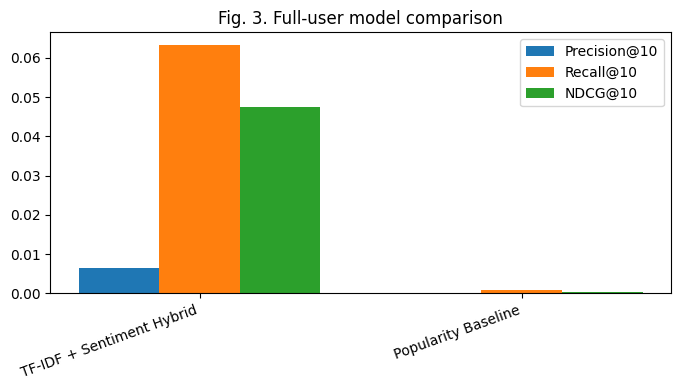

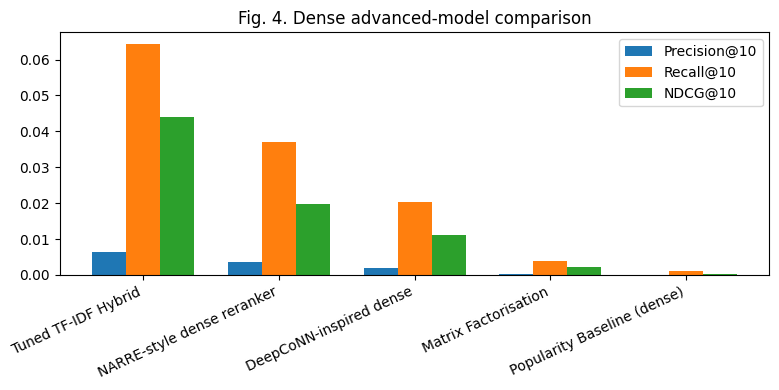

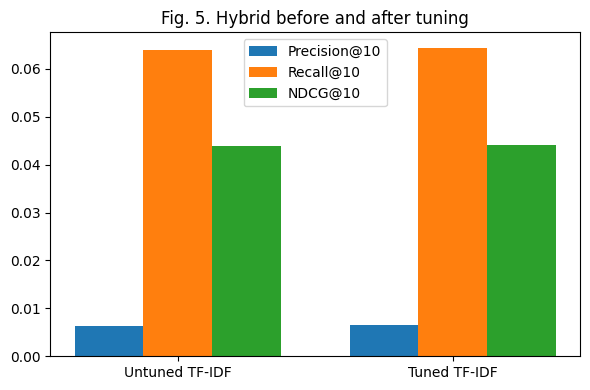

In [42]:
# Fig. 3 full-user comparison
plt.figure(figsize=(7,4))
x = np.arange(len(full_results_table))
width = 0.25
plt.bar(x - width, full_results_table["Precision@10"], width=width, label="Precision@10")
plt.bar(x, full_results_table["Recall@10"], width=width, label="Recall@10")
plt.bar(x + width, full_results_table["NDCG@10"], width=width, label="NDCG@10")
plt.xticks(x, full_results_table["Model"], rotation=20, ha="right")
plt.title("Fig. 3. Full-user model comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Fig. 4 dense comparison
plt.figure(figsize=(8,4))
x = np.arange(len(dense_results_table))
width = 0.25
plt.bar(x - width, dense_results_table["Precision@10"], width=width, label="Precision@10")
plt.bar(x, dense_results_table["Recall@10"], width=width, label="Recall@10")
plt.bar(x + width, dense_results_table["NDCG@10"], width=width, label="NDCG@10")
plt.xticks(x, dense_results_table["Model"], rotation=25, ha="right")
plt.title("Fig. 4. Dense advanced-model comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Fig. 5 tuning impact
before_after = pd.DataFrame([
    {"Model": "Untuned TF-IDF", **evaluate_recommender(dense_test_users, dense_test_user_items, lambda user_id, k=10: recommend_tfidf_dense(user_id, k=k), k=10)},
    {"Model": "Tuned TF-IDF", **results_tfidf_dense},
])

plt.figure(figsize=(6,4))
x = np.arange(len(before_after))
width = 0.25
plt.bar(x - width, before_after["Precision@10"], width=width, label="Precision@10")
plt.bar(x, before_after["Recall@10"], width=width, label="Recall@10")
plt.bar(x + width, before_after["NDCG@10"], width=width, label="NDCG@10")
plt.xticks(x, before_after["Model"])
plt.title("Fig. 5. Hybrid before and after tuning")
plt.legend()
plt.tight_layout()
plt.show()

Table VI. Recommendation overlap


,Metric,Value
0,Mean overlap @10,0.0440
1,Median overlap @10,0.0000
2,Mean Jaccard @10,0.0023
3,Median Jaccard @10,0.0000


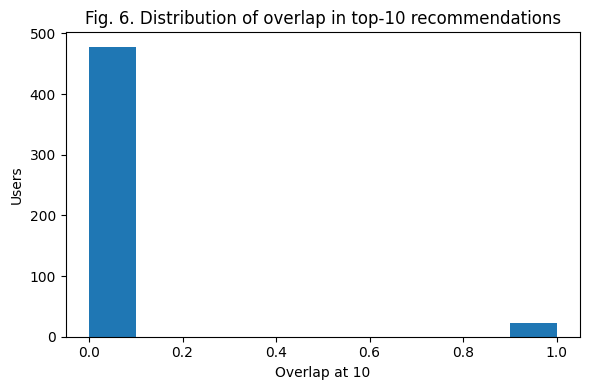

In [43]:
# overlap between popularity and TF-IDF on a sample of users
sample_users = broad_eval_users[:500] if len(broad_eval_users) > 500 else broad_eval_users

overlap_rows = []
for uid in sample_users:
    pop_set = set(recommend_popularity(uid, k=10))
    tfidf_set = set(recommend_tfidf_hybrid_full(uid, k=10))
    overlap = len(pop_set & tfidf_set)
    union = len(pop_set | tfidf_set)
    jaccard = overlap / union if union > 0 else 0.0
    overlap_rows.append({"user_id": uid, "overlap_at_10": overlap, "jaccard_at_10": jaccard})

overlap_df = pd.DataFrame(overlap_rows)
overlap_table = pd.DataFrame({
    "Value": [
        round(overlap_df["overlap_at_10"].mean(), 4),
        round(overlap_df["overlap_at_10"].median(), 4),
        round(overlap_df["jaccard_at_10"].mean(), 4),
        round(overlap_df["jaccard_at_10"].median(), 4),
    ]
}, index=["Mean overlap @10", "Median overlap @10", "Mean Jaccard @10", "Median Jaccard @10"]).reset_index().rename(columns={"index": "Metric"})

print("Table VI. Recommendation overlap")
display(overlap_table)

plt.figure(figsize=(6,4))
plt.hist(overlap_df["overlap_at_10"], bins=10)
plt.title("Fig. 6. Distribution of overlap in top-10 recommendations")
plt.xlabel("Overlap at 10")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

## 15. Customer segmentation

In [44]:
user_profile = (
    broad_train.groupby("user_id")
    .agg(
        review_count=("item_id", "size"),
        avg_rating=("rating", "mean"),
        verified_ratio=("verified_num", "mean"),
        avg_price=("price_num", "mean"),
        avg_sentiment=("sent_score", "mean"),
        avg_gap=("rating_sent_gap", "mean"),
    )
    .reset_index()
)

for col in ["avg_price"]:
    user_profile[col] = user_profile[col].fillna(user_profile[col].median())

features = ["review_count", "avg_rating", "verified_ratio", "avg_price", "avg_sentiment", "avg_gap"]
X = StandardScaler().fit_transform(user_profile[features])
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
user_profile["segment"] = kmeans.fit_predict(X)

segment_summary = user_profile.groupby("segment").agg(
    users=("user_id", "size"),
    review_count=("review_count", "mean"),
    avg_rating=("avg_rating", "mean"),
    verified_ratio=("verified_ratio", "mean"),
    avg_price=("avg_price", "mean"),
    avg_sentiment=("avg_sentiment", "mean"),
    avg_gap=("avg_gap", "mean"),
).reset_index()

print("Table IV. Segment characteristics")
display(segment_summary)

# attach segment back safely for demo/output use
segment_map = user_profile.set_index("user_id")["segment"]

for name in ["df", "broad_train", "broad_test"]:
    frame = globals()[name].copy()
    if "segment" in frame.columns:
        frame = frame.drop(columns=["segment"])
    frame["segment"] = frame["user_id"].map(segment_map)
    globals()[name] = frame

main_findings_table = pd.DataFrame([
    {
        "Finding": "Best broad-user model",
        "Model": full_results_table.iloc[0]["Model"],
        "NDCG@10": round(float(full_results_table.iloc[0]["NDCG@10"]), 6),
    },
    {
        "Finding": "Best dense advanced model",
        "Model": dense_results_table.iloc[0]["Model"],
        "NDCG@10": round(float(dense_results_table.iloc[0]["NDCG@10"]), 6),
    },
])

print("Table IVb. Main findings summary")
display(main_findings_table)


Table IV. Segment characteristics


,segment,users,review_count,avg_rating,verified_ratio,avg_price,avg_sentiment,avg_gap
0,0,20139,3.446348,3.137406,0.986999,20.122150,0.037170,0.269459
1,1,52371,4.988142,4.820344,0.988920,20.123139,0.100857,0.423574
2,2,3536,3.253111,3.961881,0.184369,26.777811,0.041454,0.375605
3,3,1,31922.000000,4.408872,0.972464,19.435682,0.104074,0.374557


Table IVb. Main findings summary


,Finding,Model,NDCG@10
0,Best broad-user model,TF-IDF + Sentiment Hybrid,0.047567
1,Best dense advanced model,Tuned TF-IDF Hybrid,0.044015


In [45]:
# dominant category and brand by segment
segment_actions = []

for seg in sorted(df["segment"].dropna().unique()):
    temp = df[df["segment"] == seg].copy()
    dominant_category = temp["category"].value_counts().index[0] if len(temp) else ""
    dominant_brand = temp["brand"].value_counts().index[0] if len(temp) else ""
    avg_sent = temp["sent_score"].mean() if len(temp) else 0.0
    avg_gap = temp["rating_sent_gap"].mean() if len(temp) else 0.0

    if avg_sent >= 0.08 and avg_gap < 0.40:
        action = "Promote premium and highly rated similar products"
    elif avg_sent >= 0.04:
        action = "Promote category-similar products with strong review signals"
    else:
        action = "Use discount or reassurance-focused marketing"

    segment_actions.append({
        "segment": int(seg),
        "dominant_category": dominant_category,
        "dominant_brand": dominant_brand,
        "avg_sentiment": round(avg_sent, 6),
        "avg_gap": round(avg_gap, 6),
        "suggested_marketing_action": action,
    })

segment_actions = pd.DataFrame(segment_actions)
print("Table V. Segment-level targeted marketing actions")
display(segment_actions)

Table V. Segment-level targeted marketing actions


,segment,dominant_category,dominant_brand,avg_sentiment,avg_gap,suggested_marketing_action
0,0,Pet_Supplies,KONG,0.052708,0.296336,Promote category-similar products with strong review signals
1,1,Pet_Supplies,KONG,0.097629,0.400404,Promote category-similar products with strong review signals
2,2,Grocery_and_Gourmet_Food,OtterBox,0.041826,0.366879,Promote category-similar products with strong review signals
3,3,Pet_Supplies,KONG,0.104070,0.374561,Promote premium and highly rated similar products


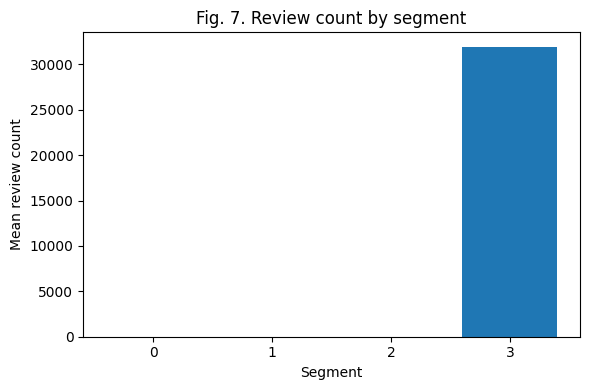

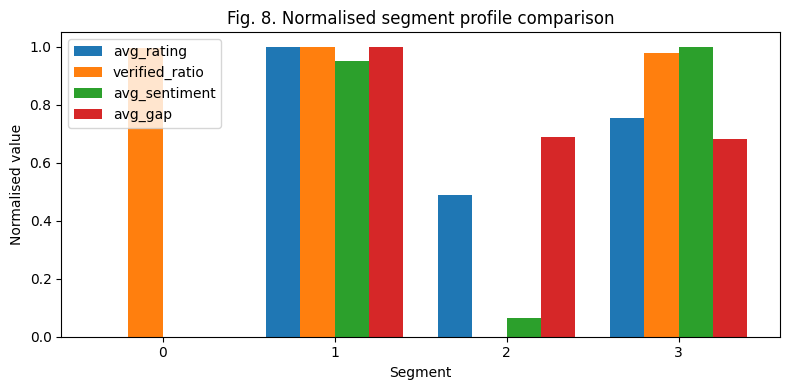

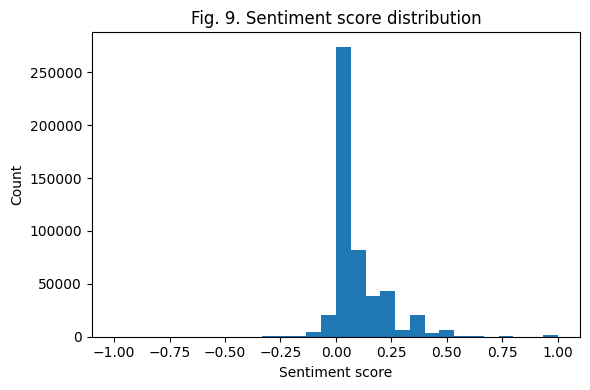

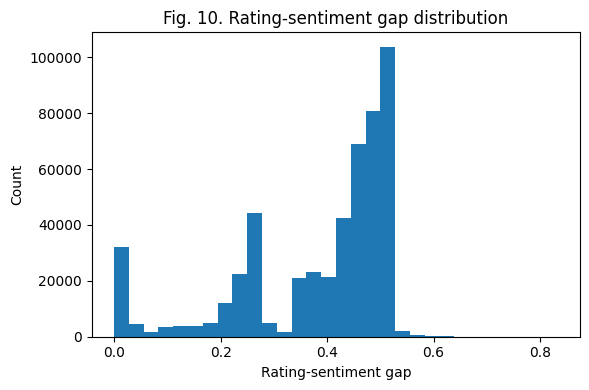

In [46]:
# Fig. 7 review count by segment
plt.figure(figsize=(6, 4))
plt.bar(segment_summary["segment"].astype(str), segment_summary["review_count"])
plt.title("Fig. 7. Review count by segment")
plt.xlabel("Segment")
plt.ylabel("Mean review count")
plt.tight_layout()
plt.show()

# Fig. 8 normalised segment profile comparison
small_cols = ["avg_rating", "verified_ratio", "avg_sentiment", "avg_gap"]
temp_plot = segment_summary[["segment"] + small_cols].copy()

for col in small_cols:
    col_min = temp_plot[col].min()
    col_max = temp_plot[col].max()
    if col_max > col_min:
        temp_plot[col] = (temp_plot[col] - col_min) / (col_max - col_min)
    else:
        temp_plot[col] = 0.0

x = np.arange(len(temp_plot))
width = 0.2

plt.figure(figsize=(8, 4))
plt.bar(x - 1.5 * width, temp_plot["avg_rating"], width=width, label="avg_rating")
plt.bar(x - 0.5 * width, temp_plot["verified_ratio"], width=width, label="verified_ratio")
plt.bar(x + 0.5 * width, temp_plot["avg_sentiment"], width=width, label="avg_sentiment")
plt.bar(x + 1.5 * width, temp_plot["avg_gap"], width=width, label="avg_gap")
plt.xticks(x, temp_plot["segment"].astype(str))
plt.title("Fig. 8. Normalised segment profile comparison")
plt.xlabel("Segment")
plt.ylabel("Normalised value")
plt.legend()
plt.tight_layout()
plt.show()

# Fig. 9 sentiment distribution
plt.figure(figsize=(6, 4))
plt.hist(df["sent_score"], bins=30)
plt.title("Fig. 9. Sentiment score distribution")
plt.xlabel("Sentiment score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Fig. 10 rating-sentiment gap distribution
plt.figure(figsize=(6, 4))
plt.hist(df["rating_sent_gap"], bins=30)
plt.title("Fig. 10. Rating-sentiment gap distribution")
plt.xlabel("Rating-sentiment gap")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 16. Review-based consumer behaviour summary

In [47]:
behaviour_summary = pd.DataFrame({
    "Metric": [
        "Average rating",
        "Average sentiment score",
        "Average rating-sentiment gap",
        "Share of verified reviews",
        "Average votes",
        "Average price"
    ],
    "Value": [
        round(df["rating"].mean(), 4),
        round(df["sent_score"].mean(), 6),
        round(df["rating_sent_gap"].mean(), 6),
        round(df["verified_num"].mean(), 6),
        round(df["vote_num"].mean(), 6),
        round(df["price_num"].mean(skipna=True), 4),
    ]
})
print("Table VII. Review-based consumer behaviour summary")
display(behaviour_summary)

Table VII. Review-based consumer behaviour summary


,Metric,Value
0,Average rating,4.343600
1,Average sentiment score,0.085225
2,Average rating-sentiment gap,0.377961
3,Share of verified reviews,0.948900
4,Average votes,0.120799
5,Average price,20.359000


## 17. Offline recommendation demo

In [48]:
# lookup table for display
item_lookup = (
    df[[c for c in ["item_id", "item_name", "brand", "category", "price_num", "rating"] if c in df.columns]]
    .drop_duplicates(subset=["item_id"])
    .copy()
)

def items_for_display(item_ids):
    if item_ids is None or len(item_ids) == 0:
        return pd.DataFrame(columns=[c for c in ["item_id", "item_name", "brand", "category", "price_num", "rating"] if c in item_lookup.columns])
    item_ids = list(pd.Series(item_ids).dropna().unique())
    out = item_lookup[item_lookup["item_id"].isin(item_ids)].copy()
    order_map = {item_id: i for i, item_id in enumerate(item_ids)}
    out["__rank"] = out["item_id"].map(order_map)
    out = out.sort_values("__rank").drop(columns="__rank")
    return out.reset_index(drop=True)

def recommend_for_existing_user(user_id, k=5):
    user_id = int(user_id)
    output = {
        "popularity": items_for_display(recommend_popularity(user_id, k=k)),
        "tfidf_sentiment_hybrid": items_for_display(recommend_tfidf_hybrid_full(user_id, k=k)),
    }
    # advanced models only if user exists in dense set
    output["matrix_factorisation"] = items_for_display(recommend_mf_dense(user_id, k=k)) if user_id in dense_train_user_items else pd.DataFrame()
    output["deepconn_inspired"] = items_for_display(recommend_deepconn_dense(user_id, k=k)) if user_id in dense_train_user_items else pd.DataFrame()
    output["narre_style"] = items_for_display(recommend_narre_dense(user_id, k=k)) if user_id in dense_train_user_items else pd.DataFrame()
    return output

In [49]:
# choose one user from each available segment for demonstration
demo_rows = []
segment_to_users = broad_test.dropna(subset=["segment"]).groupby("segment")["user_id"].first().to_dict()

for seg, uid in segment_to_users.items():
    uid = int(uid)
    hist_categories = broad_train.loc[broad_train["user_id"] == uid, "category"].dropna().astype(str).tolist()
    hist_categories = ", ".join(pd.Series(hist_categories).value_counts().head(3).index.tolist()) if len(hist_categories) else ""

    true_item_series = broad_test.loc[broad_test["user_id"] == uid, "item_name"]
    true_item = true_item_series.iloc[0] if len(true_item_series) else ""

    recs = recommend_for_existing_user(uid, k=5)

    row = {
        "segment": int(seg),
        "user_id": uid,
        "history_categories": hist_categories,
        "true_test_item_name": true_item,
        "pop_top1": recs["popularity"]["item_name"].iloc[0] if len(recs["popularity"]) else "",
        "tfidf_top1": recs["tfidf_sentiment_hybrid"]["item_name"].iloc[0] if len(recs["tfidf_sentiment_hybrid"]) else "",
        "mf_top1": recs["matrix_factorisation"]["item_name"].iloc[0] if len(recs["matrix_factorisation"]) else "",
        "deepconn_top1": recs["deepconn_inspired"]["item_name"].iloc[0] if len(recs["deepconn_inspired"]) else "",
        "narre_top1": recs["narre_style"]["item_name"].iloc[0] if len(recs["narre_style"]) else "",
    }
    demo_rows.append(row)

paper_demo_table = pd.DataFrame(demo_rows)
print("Table VIII. Example recommendations for selected users")
display(paper_demo_table)

Table VIII. Example recommendations for selected users


,segment,user_id,history_categories,true_test_item_name,pop_top1,tfidf_top1,mf_top1,deepconn_top1,narre_top1
0,0,5,Pet_Supplies,KONG Cat Tennis Balls with Bells,"CeeOne 27W 5.4A Dual-Port Type C USB Car Charger with Built-in 3.3FT USB Type C Cable for Apple New Macbook 12 Inch,...","Earth Rated Dog Poop Bags, Extra Thick and Strong Poop Bags for Dogs, Guaranteed Leak-Proof","Toblerone Swiss Milk Chocolate Bar, Crunchy Salted Almond, 3.52 Ounce","Blue Buffalo Basics Limited Ingredient Diet, Grain Free Natural Adult Small Breed Dry Dog Food, Lamb &amp; Potato",Gamma2 Vittles Vault Plus for Pet Food Storage
1,1,1,"Pet_Supplies, Grocery_and_Gourmet_Food, Office_Products",French's Mustard Packets - 5.5g/100 ct. Packets,"CeeOne 27W 5.4A Dual-Port Type C USB Car Charger with Built-in 3.3FT USB Type C Cable for Apple New Macbook 12 Inch,...",Milk-Bone Flavor Snacks Dog Treats,"ZippyPaws - Skinny Peltz No Stuffing Squeaky Plush Dog Toy, Fox, Raccoon, and Squirrel",Pet Zone Designer Diner Adjustable Elevated Pet Feeder Raised Dog Bowls Dog Feeding Station Double Bowl Stand Stainl...,AmazonBasics Single Door &amp; Double Door Folding Metal Dog Crate
2,2,3,Arts_Crafts_and_Sewing,"Patons Classic Wool Roving Yarn, 3.5 oz, Cherry, 1 Ball","CeeOne 27W 5.4A Dual-Port Type C USB Car Charger with Built-in 3.3FT USB Type C Cable for Apple New Macbook 12 Inch,...","Platinum Soft Core Colored Pencils with Tin Case, Pack of 72",,,
3,3,0,"Pet_Supplies, Grocery_and_Gourmet_Food, Office_Products",Rio Beach Deluxe 6ft Sun Protection Beach Umbrella with Tilt,"CeeOne 27W 5.4A Dual-Port Type C USB Car Charger with Built-in 3.3FT USB Type C Cable for Apple New Macbook 12 Inch,...",ESK COLLECTION Blue 45&quot; Pet Puppy Dog Playpen Exercise Pen Kennel 600d Oxford Cloth,SmartCat All Natural Clumping Litter,"The Candlemaker's Store 05417002641 Natural Soy Wax, 10 lb. Bag, White","McCormick Lemon Extract, 8 fl oz"


In [50]:
# Optional: top-1 hit summary against held-out item
def top1_match(true_name, predicted_name):
    if pd.isna(true_name) or pd.isna(predicted_name):
        return 0
    return int(str(true_name).strip() == str(predicted_name).strip())

if len(paper_demo_table) > 0:
    for pred_col in ["pop_top1", "tfidf_top1", "mf_top1", "deepconn_top1", "narre_top1"]:
        paper_demo_table[pred_col.replace("_top1", "_hit")] = paper_demo_table.apply(
            lambda r: top1_match(r["true_test_item_name"], r[pred_col]), axis=1
        )
    display(
        paper_demo_table[
            ["user_id", "segment", "true_test_item_name", "pop_hit", "tfidf_hit", "mf_hit", "deepconn_hit", "narre_hit"]
        ]
    )

,user_id,segment,true_test_item_name,pop_hit,tfidf_hit,mf_hit,deepconn_hit,narre_hit
0,5,0,KONG Cat Tennis Balls with Bells,0,0,0,0,0
1,1,1,French's Mustard Packets - 5.5g/100 ct. Packets,0,0,0,0,0
2,3,2,"Patons Classic Wool Roving Yarn, 3.5 oz, Cherry, 1 Ball",0,0,0,0,0
3,0,3,Rio Beach Deluxe 6ft Sun Protection Beach Umbrella with Tilt,0,0,0,0,0


## 18. Save paper outputs

In [51]:
dataset_summary.to_csv(OUTPUT_DIR / "table_dataset_summary.csv", index=False)
full_results_table.to_csv(OUTPUT_DIR / "table_full_user_results.csv", index=False)
dense_results_table.to_csv(OUTPUT_DIR / "table_dense_results.csv", index=False)
tuning_table.to_csv(OUTPUT_DIR / "table_tuning_results.csv", index=False)
segment_summary.to_csv(OUTPUT_DIR / "table_segment_summary.csv", index=False)
main_findings_table.to_csv(OUTPUT_DIR / "table_main_findings.csv", index=False)
segment_actions.to_csv(OUTPUT_DIR / "table_segment_actions.csv", index=False)
behaviour_summary.to_csv(OUTPUT_DIR / "table_behaviour_summary.csv", index=False)
paper_demo_table.to_csv(OUTPUT_DIR / "table_example_recommendations.csv", index=False)

print("Saved tables to:", OUTPUT_DIR)


Saved tables to: project_outputs
